This time, the data split will be dependant on the patient to avoid data leakage.

Again, the first step will be to mount Google Drive to have access to the needed dataset


In [3]:
from google.colab import drive
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

# Google drive mount (it is only needed once, but it is better to include it)
drive.mount('/content/drive')
print("Google Drive connected sucessfully. Eeverything is ready for a Patient-level split.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected sucessfully. Eeverything is ready for a Patient-level split.


In this code cell, the algorithm for a Patient-Level Split is implmented

In [3]:
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

def get_patient_id(filename):
    """
    Extracts a unique ID from the patient.
    For example: SOB_B_A-14-22549AB-40-001.png -> Extracts '14-22549AB'
    """
    parts = filename.split('-')
    if len(parts) >= 3:
        return f"{parts[1]}-{parts[2]}"
    return filename

def process_dataset_patient_split(origin_path, final_path='data_split', train_size=0.8, seed=42):
    random.seed(seed)
    origin = Path(origin_path)
    final_p = Path(final_path)

    if final_p.exists():
        print(f"Erasing old directory '{final_p}'...")
        shutil.rmtree(final_p)

    # Create structure with folders
    train_b_dir = final_p / 'train' / 'benign'
    train_m_dir = final_p / 'train' / 'malignant'
    test_b_dir = final_p / 'test' / 'benign'
    test_m_dir = final_p / 'test' / 'malignant'

    for d in [train_b_dir, train_m_dir, test_b_dir, test_m_dir]:
        d.mkdir(parents=True, exist_ok=True)

    zooms = [f.name for f in origin.iterdir() if f.is_dir()]
    print(f"Detected zooms: {zooms}\n")

    extensions = ('*.png', '*.jpg', '*.jpeg', '*.tiff', '*.bmp')
    total_train, total_test = 0, 0

    for amp in zooms:
        path_b_zoom = origin / amp / 'benign'
        path_m_zoom = origin / amp / 'malignant'

        if not path_b_zoom.exists() or not path_m_zoom.exists():
            continue

        # 1. Group images by the patient's ID
        dict_patients_b = {}
        for ext in extensions:
            for img in path_b_zoom.glob(ext):
                p_id = get_patient_id(img.name)
                if p_id not in dict_patients_b:
                    dict_patients_b[p_id] = []
                dict_patients_b[p_id].append(img)

        dict_patients_m = {}
        for ext in extensions:
            for img in path_m_zoom.glob(ext):
                p_id = get_patient_id(img.name)
                if p_id not in dict_patients_m:
                    dict_patients_m[p_id] = []
                dict_patients_m[p_id].append(img)

        if not dict_patients_b or not dict_patients_m:
            continue

        patients_b = list(dict_patients_b.keys())
        patients_m = list(dict_patients_m.keys())

        # 2. Balance the weights at a patient's level
        target_size = min(len(patients_b), len(patients_m))
        patients_b_bal = random.sample(patients_b, target_size)
        patients_m_bal = random.sample(patients_m, target_size)

        # 3. Divide patients (not individual images) into Train and Test
        train_patients_b, test_patients_b = train_test_split(patients_b_bal, train_size=train_size, random_state=seed)
        train_patients_m, test_patients_m = train_test_split(patients_m_bal, train_size=train_size, random_state=seed)

        # 4. Copy hermetically (strictly preventing leakage)
        def copy_by_patients(patient_list, patient_dict, dest_folder):
            count = 0
            for p_id in patient_list:
                for img_file in patient_dict[p_id]:
                    # Add zoom prefix to avoid overwriting files with the same name
                    shutil.copy(img_file, dest_folder / f"{amp}_{img_file.name}")
                    count += 1
            return count

        b_train_count = copy_by_patients(train_patients_b, dict_patients_b, train_b_dir)
        b_test_count = copy_by_patients(test_patients_b, dict_patients_b, test_b_dir)
        m_train_count = copy_by_patients(train_patients_m, dict_patients_m, train_m_dir)
        m_test_count = copy_by_patients(test_patients_m, dict_patients_m, test_m_dir)

        print(f" Zoom {amp} processed (Patient-Level Split):")
        print(f"   - Patients per class: {target_size} (Train: {len(train_patients_b)} | Test: {len(test_patients_b)})")
        print(f"   - Images in TRAIN: {b_train_count} benigns | {m_train_count} malignants")
        print(f"   - Images in TEST : {b_test_count} benigns | {m_test_count} malignants\n")

        total_train += b_train_count + m_train_count
        total_test += b_test_count + m_test_count

    print("-" * 50)
    print(f"The patient-level split has finished successfully.")
    print(f"New clean data stored in: '{final_path}/'")
    print(f"Total images in TRAIN: {total_train}")
    print(f"Total images in TEST: {total_test}")

# =====================================================================
# EXECUTION
# =====================================================================
source_path = '/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification'
local_dest_path = '/content/data_split'

process_dataset_patient_split(origin_path=source_path, final_path=local_dest_path)

Detected zooms: ['100X', '400X', '40X', '200X']

 Zoom 100X processed (Patient-Level Split):
   - Patients per class: 24 (Train: 19 | Test: 5)
   - Images in TRAIN: 501 benigns | 468 malignants
   - Images in TEST : 143 benigns | 152 malignants

 Zoom 400X processed (Patient-Level Split):
   - Patients per class: 24 (Train: 19 | Test: 5)
   - Images in TRAIN: 498 benigns | 397 malignants
   - Images in TEST : 90 benigns | 136 malignants

 Zoom 40X processed (Patient-Level Split):
   - Patients per class: 24 (Train: 19 | Test: 5)
   - Images in TRAIN: 494 benigns | 478 malignants
   - Images in TEST : 131 benigns | 109 malignants

 Zoom 200X processed (Patient-Level Split):
   - Patients per class: 24 (Train: 19 | Test: 5)
   - Images in TRAIN: 508 benigns | 479 malignants
   - Images in TEST : 115 benigns | 113 malignants

--------------------------------------------------
The patient-level split has finished successfully.
New clean data stored in: '/content/data_split/'
Total images i

As the data is correctly splitted and prepared, the next step is to train the CNN model without data augmentation

1. Data Loaders

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [4]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Strict preprocessing (NO Data Augmentation)
transform_no_da = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load data from the new patient-split folders
train_dataset = datasets.ImageFolder(root='/content/data_split/train', transform=transform_no_da)
test_dataset = datasets.ImageFolder(root='/content/data_split/test', transform=transform_no_da)

# DataLoaders (using batch_size=32, which is ideal for ResNet18 in Colab)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

print(f"Total Train images: {len(train_dataset)}")
print(f"Total Test images: {len(test_dataset)}")
print(f"Detected classes: {train_dataset.class_to_idx}")

Total Train images: 3823
Total Test images: 989
Detected classes: {'benign': 0, 'malignant': 1}


2. Initialise the CNN model without data augmentation

In [5]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Device configuration
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True
    print("Training on CUDA GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Training on CPU")

# Load pre-trained ResNet18
weights = models.ResNet18_Weights.IMAGENET1K_V1
model_cnn = models.resnet18(weights=weights)

# Ensure all layers are unfrozen (for full fine-tuning)
for param in model_cnn.parameters():
    param.requires_grad = True

# Modify the final layer for binary classification (2 classes)
num_ftrs = model_cnn.fc.in_features
model_cnn.fc = nn.Linear(num_ftrs, 2)
model_cnn = model_cnn.to(device)

# Standard loss function and optimizer for CNN
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.0001)

print("ResNet18 architecture (No DA) ready for the clean experiment.")

Training on CPU
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


ResNet18 architecture (No DA) ready for the clean experiment.


3. Train and save the model

In [ ]:
import time

NUM_EPOCHS = 15
print("Starting training for the clean experiment (Patient-Level Split)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_cnn.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model_cnn(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # ==========================================
    # VALIDATION (TEST) PHASE
    # ==========================================
    model_cnn.eval()
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_cnn(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nTraining finished successfully.")

# Save the model with a name indicating it is the clean split
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/3_cnn_unfrozen_no_DA_patient_split.pth"
torch.save(model_cnn.state_dict(), save_path)
print(f"Model saved as '3_cnn_unfrozen_no_DA_patient_split.pth'")

Iniciando entrenamiento del experimento limpio (Patient-Level Split)...



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


4. Graphical representation of the obtained data

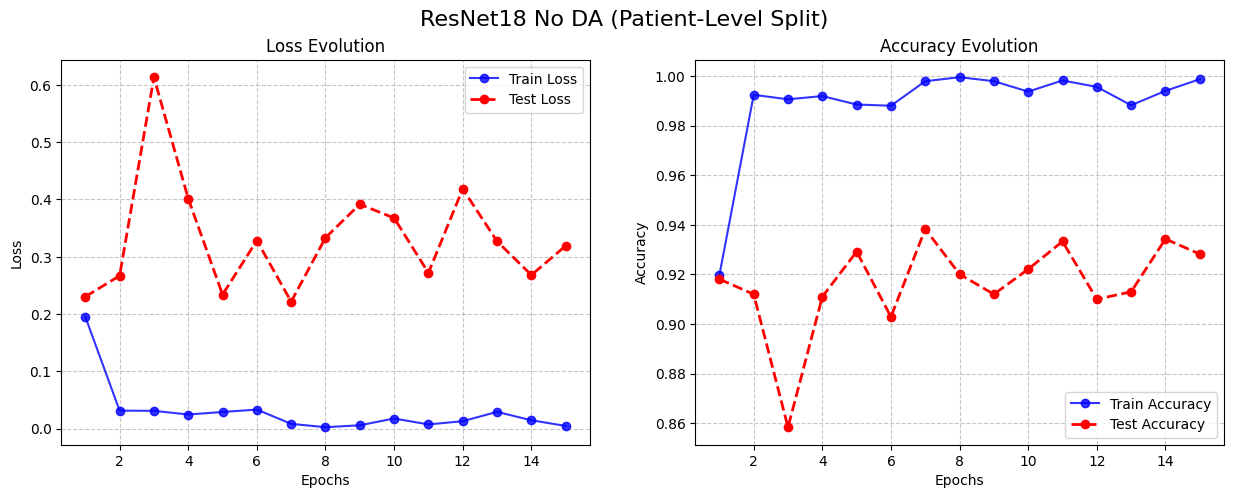

In [6]:
import matplotlib.pyplot as plt

# Data from the clean training (ResNet18 NO DA)
epochs = range(1, 16)
train_loss = [0.1953, 0.0315, 0.0311, 0.0247, 0.0291, 0.0333, 0.0084, 0.0025, 0.0059, 0.0177, 0.0074, 0.0130, 0.0293, 0.0146, 0.0048]
test_loss = [0.2303, 0.2668, 0.6133, 0.4015, 0.2339, 0.3283, 0.2216, 0.3332, 0.3916, 0.3676, 0.2719, 0.4184, 0.3270, 0.2681, 0.3190]
train_acc = [0.9197, 0.9924, 0.9906, 0.9919, 0.9885, 0.9880, 0.9979, 0.9995, 0.9979, 0.9937, 0.9982, 0.9956, 0.9882, 0.9940, 0.9987]
test_acc = [0.9181, 0.9120, 0.8584, 0.9110, 0.9292, 0.9029, 0.9383, 0.9201, 0.9120, 0.9221, 0.9333, 0.9100, 0.9130, 0.9343, 0.9282]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ResNet18 No DA (Patient-Level Split)', fontsize=16)

# Loss Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', alpha=0.8)
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Accuracy Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', alpha=0.8)
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.show()

Let's now study the same model but with data augmentation

1. Dataloaders

In [ ]:
import torch
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import time

transform_train_da = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Test ALWAYS goes without augmentations, simulating a real hospital sample
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_da = datasets.ImageFolder(root='/content/data_split/train', transform=transform_train_da)
test_dataset = datasets.ImageFolder(root='/content/data_split/test', transform=transform_test)

# Keep stable parameters for the cloud environment (num_workers=0)
train_loader_da = DataLoader(train_dataset_da, batch_size=32, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

2. Initialise the CNN model with data augmentation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_cnn_da = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model_cnn_da.parameters():
    param.requires_grad = True

num_ftrs = model_cnn_da.fc.in_features
model_cnn_da.fc = nn.Linear(num_ftrs, 2)
model_cnn_da = model_cnn_da.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn_da.parameters(), lr=0.0001)

3. Train and save the model

In [ ]:
NUM_EPOCHS = 15
print("Starting clean training WITH Data Augmentation...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # TRAINING PHASE
    model_cnn_da.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader_da:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_cnn_da(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # VALIDATION (TEST) PHASE
    model_cnn_da.eval()
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model_cnn_da(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nTraining finished successfully.")

# Save with a distinctive name
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/4_cnn_unfrozen_WITH_DA_patient_split.pth"
torch.save(model_cnn_da.state_dict(), save_path)
print(f"Model saved as '4_cnn_unfrozen_WITH_DA_patient_split.pth'")

4. Graphical representation of the obtained data

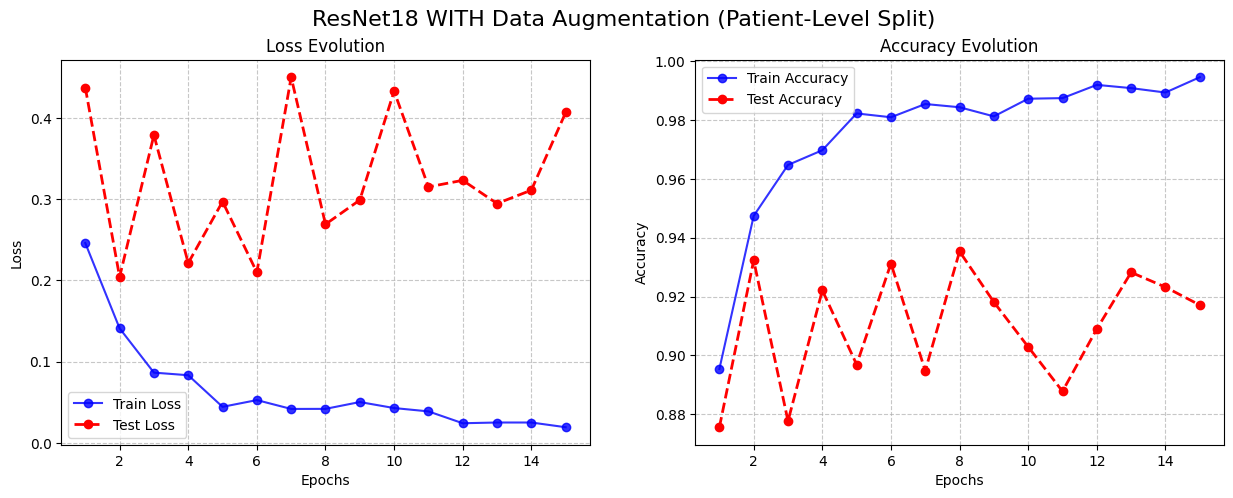

In [7]:
import matplotlib.pyplot as plt

# Data for ResNet18 WITH Data Augmentation
epochs = range(1, 16)
train_loss_da = [0.2459, 0.1409, 0.0864, 0.0832, 0.0443, 0.0526, 0.0417, 0.0418, 0.0502, 0.0428, 0.0387, 0.0241, 0.0250, 0.0250, 0.0192]
test_loss_da = [0.4373, 0.2042, 0.3788, 0.2213, 0.2969, 0.2099, 0.4500, 0.2690, 0.2988, 0.4329, 0.3150, 0.3231, 0.2945, 0.3110, 0.4066]
train_acc_da = [0.8954, 0.9474, 0.9647, 0.9697, 0.9822, 0.9809, 0.9854, 0.9843, 0.9812, 0.9872, 0.9874, 0.9919, 0.9908, 0.9893, 0.9945]
test_acc_da = [0.8756, 0.9323, 0.8777, 0.9221, 0.8969, 0.9312, 0.8948, 0.9353, 0.9181, 0.9029, 0.8878, 0.9090, 0.9282, 0.9232, 0.9171]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ResNet18 WITH Data Augmentation (Patient-Level Split)', fontsize=16)

# Loss Plot
ax1.plot(epochs, train_loss_da, 'b-o', label='Train Loss', alpha=0.8)
ax1.plot(epochs, test_loss_da, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Accuracy Plot
ax2.plot(epochs, train_acc_da, 'b-o', label='Train Accuracy', alpha=0.8)
ax2.plot(epochs, test_acc_da, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.show()

Last but not least, a graphical comparison of the CNN models with and without data augmentation

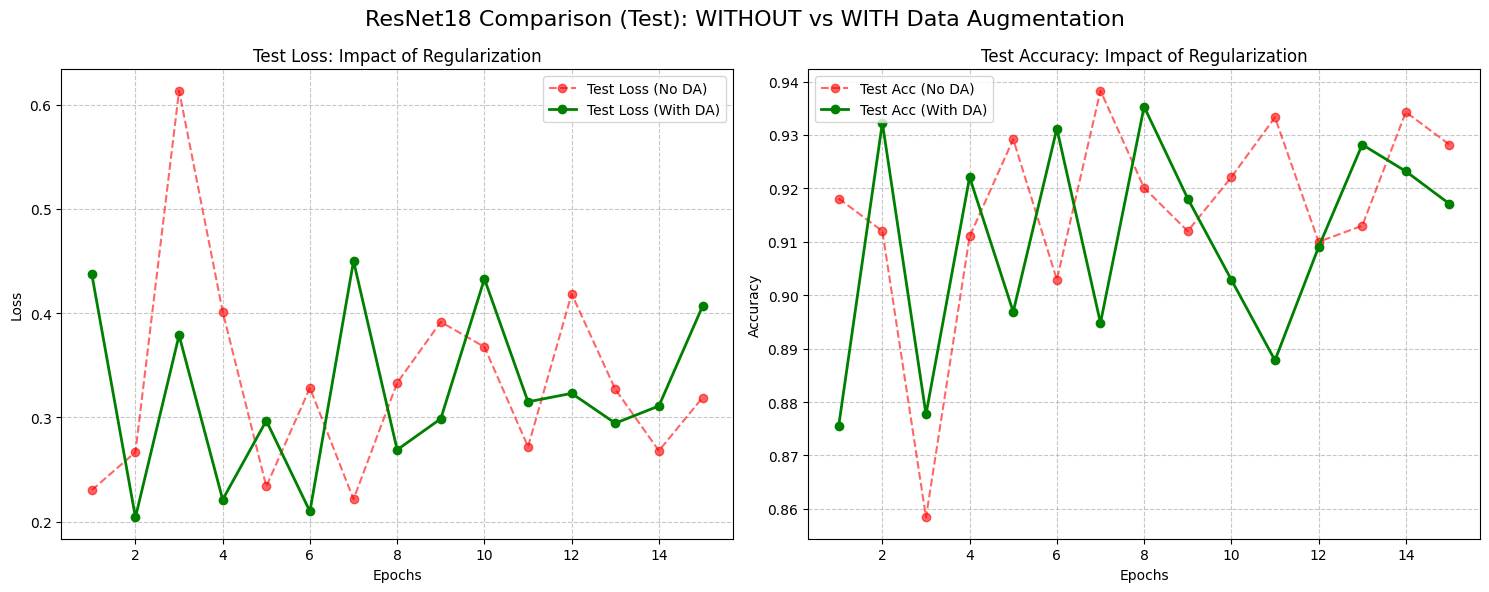

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, 16)

# Test data from the experiment WITHOUT DA
test_loss_no = [0.2303, 0.2668, 0.6133, 0.4015, 0.2339, 0.3283, 0.2216, 0.3332, 0.3916, 0.3676, 0.2719, 0.4184, 0.3270, 0.2681, 0.3190]
test_acc_no = [0.9181, 0.9120, 0.8584, 0.9110, 0.9292, 0.9029, 0.9383, 0.9201, 0.9120, 0.9221, 0.9333, 0.9100, 0.9130, 0.9343, 0.9282]

# Test data from the experiment WITH DA
test_loss_da = [0.4373, 0.2042, 0.3788, 0.2213, 0.2969, 0.2099, 0.4500, 0.2690, 0.2988, 0.4329, 0.3150, 0.3231, 0.2945, 0.3110, 0.4066]
test_acc_da = [0.8756, 0.9323, 0.8777, 0.9221, 0.8969, 0.9312, 0.8948, 0.9353, 0.9181, 0.9029, 0.8878, 0.9090, 0.9282, 0.9232, 0.9171]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ResNet18 Comparison (Test): WITHOUT vs WITH Data Augmentation', fontsize=16)

# 1. Test Loss Comparison
ax1.plot(epochs, test_loss_no, 'r--o', label='Test Loss (No DA)', alpha=0.6)
ax1.plot(epochs, test_loss_da, 'g-o', label='Test Loss (With DA)', linewidth=2)
ax1.set_title('Test Loss: Impact of Regularization')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Test Accuracy Comparison
ax2.plot(epochs, test_acc_no, 'r--o', label='Test Acc (No DA)', alpha=0.6)
ax2.plot(epochs, test_acc_da, 'g-o', label='Test Acc (With DA)', linewidth=2)
ax2.set_title('Test Accuracy: Impact of Regularization')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Now that both experiments with ResNet18 are done (CNN with and without data augmentation), let's move on to the Vision Transformers. The first one would be without data augmentation:

1. Preprocess and load data

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import time

# 1. Basic Preprocessing (No DA)
transform_no_da = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_vit_no_da = datasets.ImageFolder(root='/content/data_split/train', transform=transform_no_da)
test_dataset_vit = datasets.ImageFolder(root='/content/data_split/test', transform=transform_no_da)

train_loader_vit_no_da = DataLoader(train_dataset_vit_no_da, batch_size=32, shuffle=True, num_workers=0, pin_memory=False)
test_loader_vit = DataLoader(test_dataset_vit, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

2. Initialise the model ViT without data augmentation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active device: {device}")

model_vit_no_da = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# Ensure all layers are unfrozen
for param in model_vit_no_da.parameters():
    param.requires_grad = True

# Adapt the classification head (MLP Head) of the ViT for 2 classes
num_ftrs_vit = model_vit_no_da.heads.head.in_features
model_vit_no_da.heads.head = nn.Linear(num_ftrs_vit, 2)
model_vit_no_da = model_vit_no_da.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_vit_no_da.parameters(), lr=0.0001)

3. Train and save the model

In [ ]:
NUM_EPOCHS = 15
print("Starting ViT training WITHOUT Data Augmentation (Clean Experiment)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # TRAINING
    model_vit_no_da.train()
    running_loss, running_corrects, total_train = 0.0, 0, 0

    for inputs, labels in train_loader_vit_no_da:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model_vit_no_da(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # VALIDATION
    model_vit_no_da.eval()
    running_test_loss, running_test_corrects, total_test = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader_vit:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_vit_no_da(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test
    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

# Save model
ruta_vit_no_da = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/5_vit_unfrozen_no_DA_patient_split.pth"
torch.save(model_vit_no_da.state_dict(), ruta_vit_no_da)
print(f"\nViT model WITHOUT DA saved successfully.")

4. Graphical representation of the data

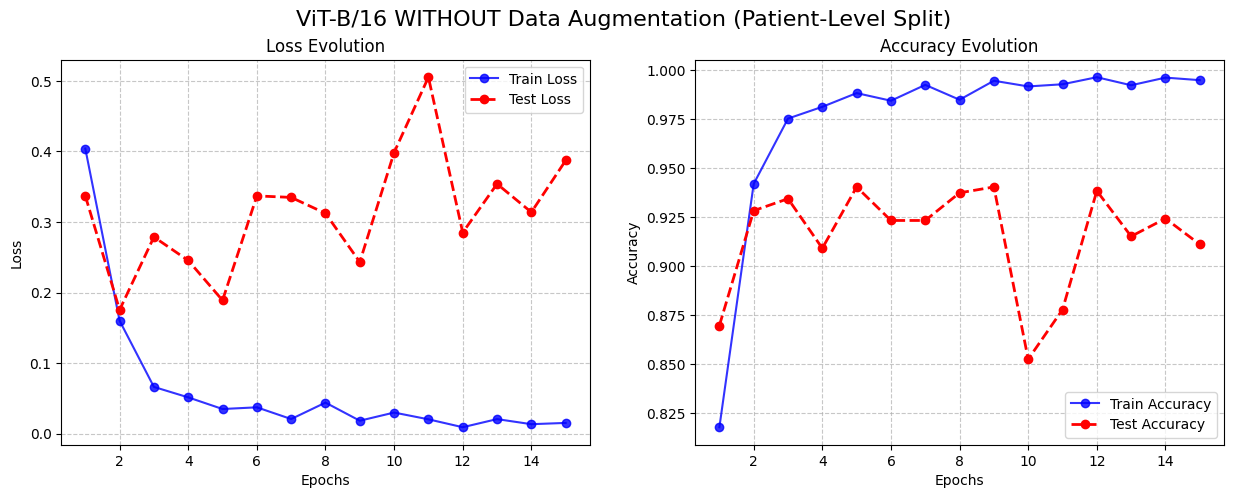

In [9]:
import matplotlib.pyplot as plt

# Training data for ViT-B/16 WITHOUT Data Augmentation (Patient-Level Split)
epochs = range(1, 16)
train_loss_vit_no = [0.4041, 0.1601, 0.0663, 0.0515, 0.0350, 0.0374, 0.0208, 0.0441, 0.0184, 0.0300, 0.0204, 0.0092, 0.0207, 0.0135, 0.0153]
test_loss_vit_no = [0.3371, 0.1755, 0.2788, 0.2455, 0.1890, 0.3370, 0.3349, 0.3123, 0.2433, 0.3985, 0.5052, 0.2851, 0.3540, 0.3139, 0.3872]
train_acc_vit_no = [0.8177, 0.9419, 0.9752, 0.9812, 0.9882, 0.9843, 0.9924, 0.9848, 0.9945, 0.9916, 0.9927, 0.9963, 0.9922, 0.9961, 0.9948]
test_acc_vit_no = [0.8696, 0.9282, 0.9343, 0.9090, 0.9403, 0.9232, 0.9232, 0.9373, 0.9403, 0.8524, 0.8777, 0.9383, 0.9151, 0.9242, 0.9110]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ViT-B/16 WITHOUT Data Augmentation (Patient-Level Split)', fontsize=16)

# Loss Plot
ax1.plot(epochs, train_loss_vit_no, 'b-o', label='Train Loss', alpha=0.8)
ax1.plot(epochs, test_loss_vit_no, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Accuracy Plot
ax2.plot(epochs, train_acc_vit_no, 'b-o', label='Train Accuracy', alpha=0.8)
ax2.plot(epochs, test_acc_vit_no, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.show()

The next step is to run the same training with a ViT model with data augmentation.

1. Load and preprocess data

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import time

# 1. Transformations with Data Augmentation for Train
transform_train_da = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_vit_da = datasets.ImageFolder(root='/content/data_split/train', transform=transform_train_da)
test_dataset_vit = datasets.ImageFolder(root='/content/data_split/test', transform=transform_test)

train_loader_vit_da = DataLoader(train_dataset_vit_da, batch_size=32, shuffle=True, num_workers=0, pin_memory=False)
test_loader_vit = DataLoader(test_dataset_vit, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

2. Initialise the ViT model with data augmentation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vit_da = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

for param in model_vit_da.parameters():
    param.requires_grad = True

model_vit_da.heads.head = nn.Linear(model_vit_da.heads.head.in_features, 2)
model_vit_da = model_vit_da.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_vit_da.parameters(), lr=0.0001)

3. Train and save the model

In [ ]:
NUM_EPOCHS = 15
print("Starting ViT training WITH Data Augmentation...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # TRAINING
    model_vit_da.train()
    running_loss, running_corrects, total_train = 0.0, 0, 0

    for inputs, labels in train_loader_vit_da:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model_vit_da(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # VALIDATION
    model_vit_da.eval()
    running_test_loss, running_test_corrects, total_test = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader_vit:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_vit_da(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test
    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

# Save model
ruta_vit_da = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/6_vit_unfrozen_WITH_DA_patient_split.pth"
torch.save(model_vit_da.state_dict(), ruta_vit_da)
print(f"\nViT model WITH DA saved successfully.")

4. Graphical representation of the data

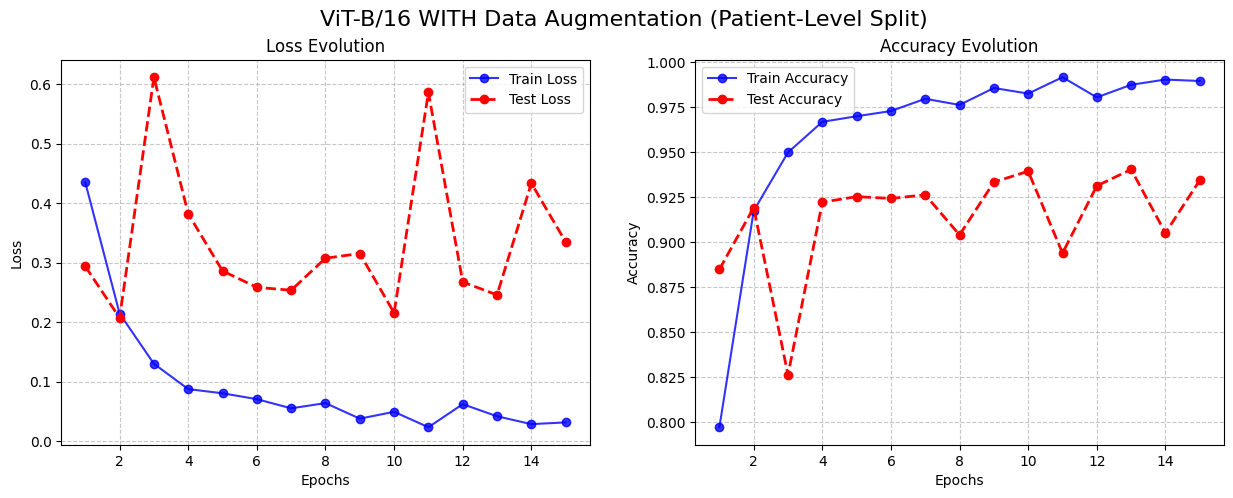

In [11]:
import matplotlib.pyplot as plt

# Data for ViT WITH Data Augmentation (Patient-Level Split)
epochs = range(1, 16)
train_loss_vit_da = [0.4348, 0.2142, 0.1298, 0.0872, 0.0802, 0.0703, 0.0549, 0.0637, 0.0375, 0.0490, 0.0231, 0.0619, 0.0415, 0.0283, 0.0312]
test_loss_vit_da = [0.2937, 0.2070, 0.6118, 0.3820, 0.2860, 0.2584, 0.2535, 0.3074, 0.3152, 0.2155, 0.5862, 0.2673, 0.2457, 0.4335, 0.3346]
train_acc_vit_da = [0.7970, 0.9173, 0.9498, 0.9668, 0.9699, 0.9728, 0.9796, 0.9762, 0.9856, 0.9825, 0.9916, 0.9804, 0.9874, 0.9903, 0.9895]
test_acc_vit_da = [0.8847, 0.9191, 0.8261, 0.9221, 0.9252, 0.9242, 0.9262, 0.9039, 0.9333, 0.9393, 0.8938, 0.9312, 0.9403, 0.9050, 0.9343]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ViT-B/16 WITH Data Augmentation (Patient-Level Split)', fontsize=16)

# Loss Plot
ax1.plot(epochs, train_loss_vit_da, 'b-o', label='Train Loss', alpha=0.8)
ax1.plot(epochs, test_loss_vit_da, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Accuracy Plot
ax2.plot(epochs, train_acc_vit_da, 'b-o', label='Train Accuracy', alpha=0.8)
ax2.plot(epochs, test_acc_vit_da, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.show()

Comparison between the ViTs with and without data augmentation:

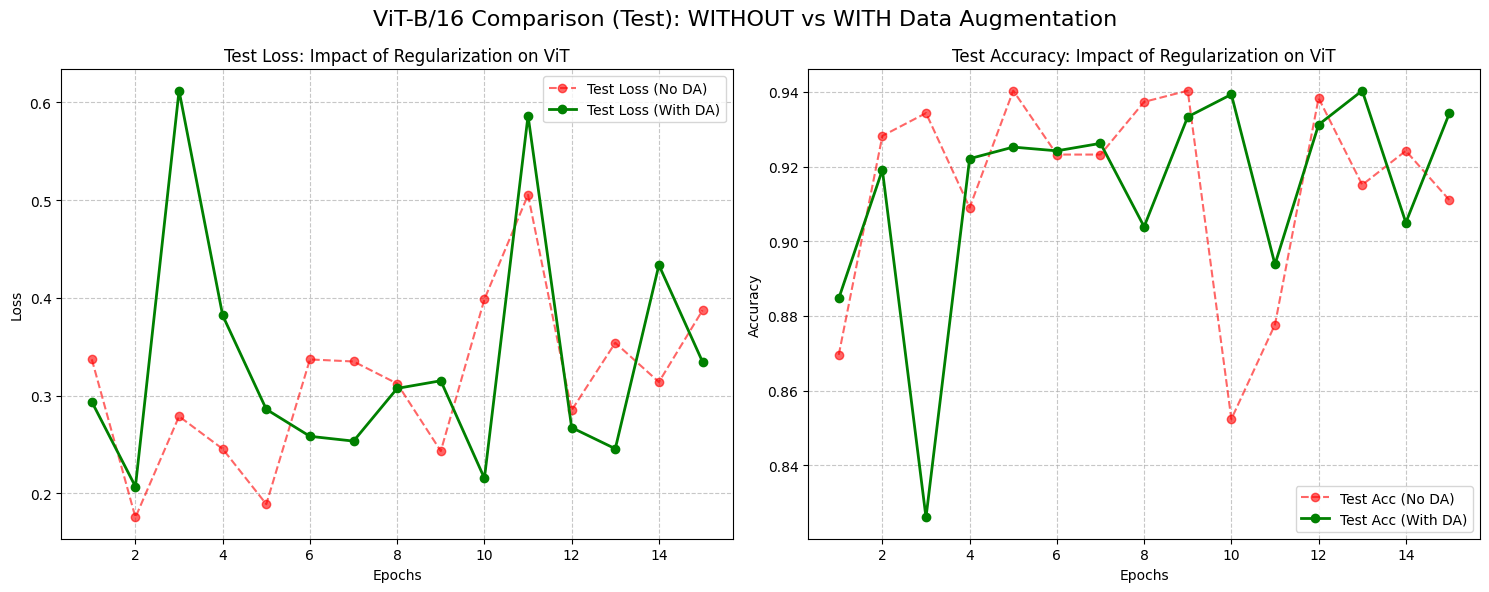

In [12]:
import matplotlib.pyplot as plt

epochs = range(1, 16)

# Test Data ViT WITHOUT DA
test_loss_vit_no = [0.3371, 0.1755, 0.2788, 0.2455, 0.1890, 0.3370, 0.3349, 0.3123, 0.2433, 0.3985, 0.5052, 0.2851, 0.3540, 0.3139, 0.3872]
test_acc_vit_no = [0.8696, 0.9282, 0.9343, 0.9090, 0.9403, 0.9232, 0.9232, 0.9373, 0.9403, 0.8524, 0.8777, 0.9383, 0.9151, 0.9242, 0.9110]

# Test Data ViT WITH DA
test_loss_vit_da = [0.2937, 0.2070, 0.6118, 0.3820, 0.2860, 0.2584, 0.2535, 0.3074, 0.3152, 0.2155, 0.5862, 0.2673, 0.2457, 0.4335, 0.3346]
test_acc_vit_da = [0.8847, 0.9191, 0.8261, 0.9221, 0.9252, 0.9242, 0.9262, 0.9039, 0.9333, 0.9393, 0.8938, 0.9312, 0.9403, 0.9050, 0.9343]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ViT-B/16 Comparison (Test): WITHOUT vs WITH Data Augmentation', fontsize=16)

# Test Loss Comparison
ax1.plot(epochs, test_loss_vit_no, 'r--o', label='Test Loss (No DA)', alpha=0.6)
ax1.plot(epochs, test_loss_vit_da, 'g-o', label='Test Loss (With DA)', linewidth=2)
ax1.set_title('Test Loss: Impact of Regularization on ViT')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Test Accuracy Comparison
ax2.plot(epochs, test_acc_vit_no, 'r--o', label='Test Acc (No DA)', alpha=0.6)
ax2.plot(epochs, test_acc_vit_da, 'g-o', label='Test Acc (With DA)', linewidth=2)
ax2.set_title('Test Accuracy: Impact of Regularization on ViT')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Since every is now done, the next graph shows the comparative of the four cases:

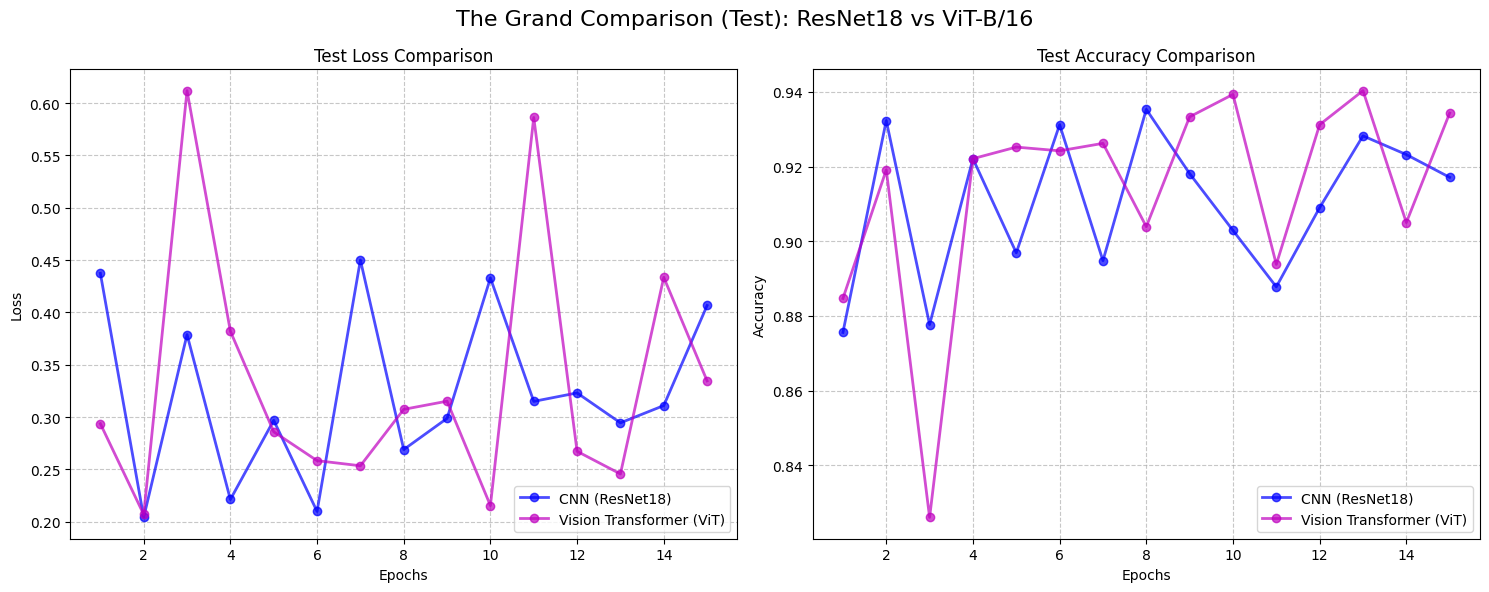

In [13]:
import matplotlib.pyplot as plt

epochs = range(1, 16)

# Test Data: CNN WITH Data Augmentation
test_loss_cnn = [0.4373, 0.2042, 0.3788, 0.2213, 0.2969, 0.2099, 0.4500, 0.2690, 0.2988, 0.4329, 0.3150, 0.3231, 0.2945, 0.3110, 0.4066]
test_acc_cnn = [0.8756, 0.9323, 0.8777, 0.9221, 0.8969, 0.9312, 0.8948, 0.9353, 0.9181, 0.9029, 0.8878, 0.9090, 0.9282, 0.9232, 0.9171]

# Test Data: ViT WITH Data Augmentation
test_loss_vit = [0.2937, 0.2070, 0.6118, 0.3820, 0.2860, 0.2584, 0.2535, 0.3074, 0.3152, 0.2155, 0.5862, 0.2673, 0.2457, 0.4335, 0.3346]
test_acc_vit = [0.8847, 0.9191, 0.8261, 0.9221, 0.9252, 0.9242, 0.9262, 0.9039, 0.9333, 0.9393, 0.8938, 0.9312, 0.9403, 0.9050, 0.9343]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('The Grand Comparison (Test): ResNet18 vs ViT-B/16', fontsize=16)

# 1. Test Loss Comparison
ax1.plot(epochs, test_loss_cnn, 'b-o', label='CNN (ResNet18)', alpha=0.7, linewidth=2)
ax1.plot(epochs, test_loss_vit, 'm-o', label='Vision Transformer (ViT)', alpha=0.7, linewidth=2)
ax1.set_title('Test Loss Comparison')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Test Accuracy Comparison
ax2.plot(epochs, test_acc_cnn, 'b-o', label='CNN (ResNet18)', alpha=0.7, linewidth=2)
ax2.plot(epochs, test_acc_vit, 'm-o', label='Vision Transformer (ViT)', alpha=0.7, linewidth=2)
ax2.set_title('Test Accuracy Comparison')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Confusion matrix of the four models:

Extracting true diagnoses from the Test Set...
Evaluating: CNN (ResNet18) - No DA...
Evaluating: CNN (ResNet18) - With DA...
Evaluating: ViT-B/16 - No DA...
Evaluating: ViT-B/16 - With DA...


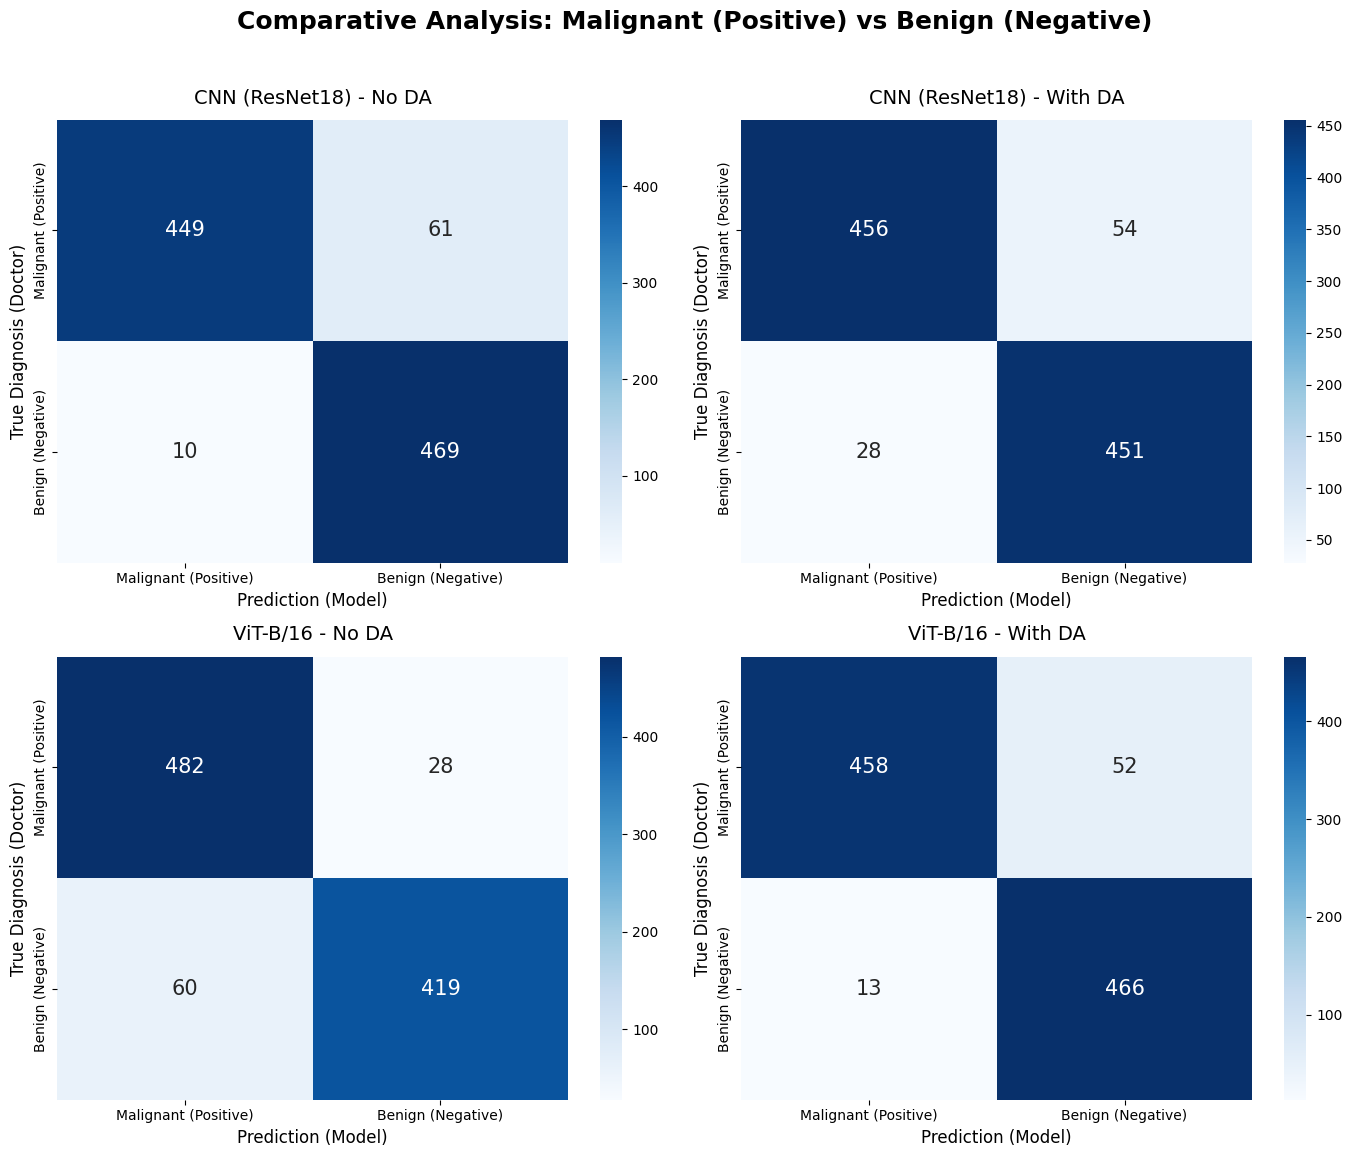

In [4]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Environment setup and Test Loader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(root='/content/data_split/test', transform=transform_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
clases = test_dataset.classes

# 2. Paths for the 4 models (Patient-Level Split)
rutas = {
    "CNN (ResNet18) - No DA": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/3_cnn_unfrozen_no_DA_patient_split.pth",
    "CNN (ResNet18) - With DA": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/4_cnn_unfrozen_WITH_DA_patient_split.pth",
    "ViT-B/16 - No DA": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/5_vit_unfrozen_no_DA_patient_split.pth",
    "ViT-B/16 - With DA": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/6_vit_unfrozen_WITH_DA_patient_split.pth"
}

# 3. Extract real labels (they are identical for all tests)
print("Extracting true diagnoses from the Test Set...")
y_real = []
for _, labels in test_loader:
    y_real.extend(labels.numpy())

matrices = {}

# 4. Evaluation Loop: Model by Model
for nombre, ruta in rutas.items():
    print(f"Evaluating: {nombre}...")

    # Build architecture
    if "CNN" in nombre:
        modelo = models.resnet18(weights=None)
        modelo.fc = nn.Linear(modelo.fc.in_features, 2)
    else:
        modelo = models.vit_b_16(weights=None)
        modelo.heads.head = nn.Linear(modelo.heads.head.in_features, 2)

    # Load weights and send to GPU
    modelo.load_state_dict(torch.load(ruta, map_location=device))
    modelo = modelo.to(device)
    modelo.eval()

    # Inference
    y_predicho = []
    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            outputs = modelo(inputs)
            _, preds = torch.max(outputs, 1)
            y_predicho.extend(preds.cpu().numpy())

    # Calculate confusion matrix
    matrices[nombre] = confusion_matrix(y_real, y_predicho)

    # Free GPU memory (Critical so Colab doesn't crash)
    del modelo
    torch.cuda.empty_cache()

# 5. Grid Visualization (2x2) ajustado a tu definición clínica
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Comparative Analysis: Malignant (Positive) vs Benign (Negative)', fontsize=18, fontweight='bold', y=0.96)

axes = axes.flatten()

# Definimos el orden para que coincida con tu imagen:
# Fila 1: Malignant (Positive)
# Fila 2: Benign (Negative)
labels_cm = ["Malignant (Positive)", "Benign (Negative)"]

for i, (nombre, cm) in enumerate(matrices.items()):
    # Invertimos la matriz para que Malignant (1) esté en la fila/columna 0
    cm_flipped = cm[::-1, ::-1] if clases[0] == "benign" else cm

    sns.heatmap(cm_flipped, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_cm, yticklabels=labels_cm,
                annot_kws={"size": 15}, ax=axes[i])

    axes[i].set_title(nombre, fontsize=14, pad=12)
    axes[i].set_ylabel('True Diagnosis (Doctor)', fontsize=12)
    axes[i].set_xlabel('Prediction (Model)', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

For the next step of this investigation, I will create a visual environment where an image can be uploaded, the user may choose a model and an answer will be given regarding whether the case is bening or malignant. This environment will be created with Gradio.

In [3]:
import gradio as gr
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# PATH TO YOUR 8 SAVED MODELS IN DRIVE
model_paths = {
  # The "Too Good To Be True" models (Put the exact name they have in your Drive)
    #"CNN (ResNet18) - TGTBT - No DA": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/2_resnet18_unfrozen_no_DA_tfg_thermography.pth",
    #"CNN (ResNet18) - TGTBT - With DA": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/2_resnet18_unfrozen_DA_tfg_thermography.pth",
   # "ViT-B/16 - TGTBT - No DA": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/2_vit_unfrozen_no_DA_tfg.pth",
    #"ViT-B/16 - TGTBT - With DA": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/2_vit_unfrozen_DA_tfg.pth",

    # The real models we trained today (These names are already correct)
    "CNN (ResNet18) - Real - No DA": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/3_cnn_unfrozen_no_DA_patient_split.pth",
    "CNN (ResNet18) - Real - With DA": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/4_cnn_unfrozen_WITH_DA_patient_split.pth",
    "ViT-B/16 - Real - No DA": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/5_vit_unfrozen_no_DA_patient_split.pth",
    "ViT-B/16 - Real - With DA": "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/6_vit_unfrozen_WITH_DA_patient_split.pth"
}

def load_model(model_name):
    if "CNN" in model_name:
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)
    else:
        model = models.vit_b_16(weights=None)
        model.heads.head = nn.Linear(model.heads.head.in_features, 2)

    model.load_state_dict(torch.load(model_paths[model_name], map_location=device))
    model = model.to(device)
    model.eval()
    return model

def predict_image(image, model_choice):
    if image is None:
        return "Please upload an image."

    model = load_model(model_choice)
    image_tensor = transform_test(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]

    # Change the order if in your dataset 0 is Malignant and 1 is Benign
    classes = ["Benign", "Malignant"]
    result_dict = {classes[i]: float(probabilities[i]) for i in range(2)}

    return result_dict

interface = gr.Interface(
    fn=predict_image,
    inputs=[
        gr.Image(type="pil", label="Upload a histopathological patch"),
        gr.Dropdown(choices=list(model_paths.keys()), value="CNN (ResNet18) - Real - With DA", label="Select AI Model")
    ],
    outputs=gr.Label(num_top_classes=2, label="Model Diagnosis"),
    title="Breast Cancer Classifier - Bachelor's Thesis Demo",
    description="Compare the performance of biased models ('Too Good To Be True') versus robust models trained with Patient-Level Split and Data Augmentation.",
    theme="huggingface"
)

interface.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(
/usr/local/lib/python3.12/dist-packages/gradio/utils.py:583: UserWarning: Cannot load huggingface. Caught Exception: Client error '404 Not Found' for url 'https://huggingface.co/api/spaces/huggingface' (Request ID: Root=1-6a576772-092a91b201079b1305744f45;1f383349-c982-4054-ad1c-3a63ded6cf2b)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404

Sorry, we can't find the page you are looking for.
  warnings.warn(f"Cannot load {theme}. Caught Exception: {str(e)}")


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0a95b9358027e74651.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [4]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

# =====================================================================
# 0. DATA LOADER SETUP
# =====================================================================
transform_train_da = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_vit_da = datasets.ImageFolder(root='/content/data_split/train', transform=transform_train_da)
test_dataset_vit = datasets.ImageFolder(root='/content/data_split/test', transform=transform_test)

train_loader_vit_da = DataLoader(train_dataset_vit_da, batch_size=32, shuffle=True, num_workers=0)
test_loader_vit = DataLoader(test_dataset_vit, batch_size=32, shuffle=False, num_workers=0)

# =====================================================================
# OPTIMIZATION SUMMARY (ViT-B/16 + Data Augmentation)
# 1. AdamW Optimizer: Replaced standard Adam with AdamW, which handles
#    weight decay much better for Vision Transformers.
# 2. Weighted Loss Function (Focal Focus): Added class weights to the
#    CrossEntropyLoss. It heavily penalizes false negatives (missing a tumor).
# 3. Learning Rate Scheduler: Added CosineAnnealingLR to smoothly
#    decrease the learning rate, helping convergence without bouncing.
# 4. Mixed Precision Training (AMP): Implemented GradScaler to speed up
#    training and reduce GPU memory consumption.
# =====================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active device: {device}")

# 1. Load ViT-B/16
model_vit_optimized = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# Unfreeze all layers
for param in model_vit_optimized.parameters():
    param.requires_grad = True

# Adapt classification head
num_ftrs_vit = model_vit_optimized.heads.head.in_features
model_vit_optimized.heads.head = nn.Linear(num_ftrs_vit, 2)
model_vit_optimized = model_vit_optimized.to(device)

# 2. Weighted Loss Function (Assuming class 0 = benign, class 1 = malignant)
# We make a False Negative cost twice as much to the network's loss
class_weights = torch.tensor([1.0, 2.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# 3. AdamW Optimizer (Better weight decay handling)
optimizer = optim.AdamW(model_vit_optimized.parameters(), lr=1e-4, weight_decay=1e-2)

# 4. Learning Rate Scheduler
NUM_EPOCHS = 15
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# 5. Mixed Precision Scaler
scaler = torch.amp.GradScaler('cuda')

print("Starting OPTIMIZED ViT training WITH Data Augmentation...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # TRAINING
    model_vit_optimized.train()
    running_loss, running_corrects, total_train = 0.0, 0, 0

    for inputs, labels in train_loader_vit_da:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # AMP Context Manager for forward pass
        with torch.amp.autocast('cuda'):
            outputs = model_vit_optimized(inputs)
            loss = criterion(outputs, labels)

        # Scaled backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    # Step the scheduler at the end of the epoch
    scheduler.step()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # VALIDATION
    model_vit_optimized.eval()
    running_test_loss, running_test_corrects, total_test = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader_vit:
            inputs, labels = inputs.to(device), labels.to(device)

            with torch.amp.autocast('cuda'):
                outputs = model_vit_optimized(inputs)
                loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test
    epoch_time = time.time() - start_time

    # Get current learning rate to display it
    current_lr = scheduler.get_last_lr()[0]

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) [LR: {current_lr:.2e}] -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

# Save model
ruta_vit_opt = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/7_vit_OPTIMIZED_WITH_DA_patient_split.pth"
torch.save(model_vit_optimized.state_dict(), ruta_vit_opt)
print(f"\nOPTIMIZED ViT model WITH DA saved successfully.")

Active device: cuda
Starting OPTIMIZED ViT training WITH Data Augmentation...

Epoch 1/15 (67.9s) [LR: 9.89e-05] -> Train Loss: 0.4518 | Train Acc: 0.7588 || Test Loss: 0.3378 | Test Acc: 0.8645
Epoch 2/15 (65.5s) [LR: 9.57e-05] -> Train Loss: 0.2644 | Train Acc: 0.8755 || Test Loss: 0.2462 | Test Acc: 0.9019
Epoch 3/15 (65.8s) [LR: 9.05e-05] -> Train Loss: 0.1638 | Train Acc: 0.9289 || Test Loss: 0.2513 | Test Acc: 0.8989
Epoch 4/15 (65.7s) [LR: 8.36e-05] -> Train Loss: 0.1122 | Train Acc: 0.9495 || Test Loss: 0.2373 | Test Acc: 0.9070
Epoch 5/15 (65.3s) [LR: 7.52e-05] -> Train Loss: 0.1130 | Train Acc: 0.9532 || Test Loss: 0.2576 | Test Acc: 0.9232
Epoch 6/15 (65.3s) [LR: 6.58e-05] -> Train Loss: 0.0666 | Train Acc: 0.9712 || Test Loss: 0.2987 | Test Acc: 0.9181
Epoch 7/15 (64.8s) [LR: 5.57e-05] -> Train Loss: 0.0477 | Train Acc: 0.9822 || Test Loss: 0.2987 | Test Acc: 0.9019
Epoch 8/15 (64.6s) [LR: 4.53e-05] -> Train Loss: 0.0336 | Train Acc: 0.9856 || Test Loss: 0.3157 | Test Acc: 

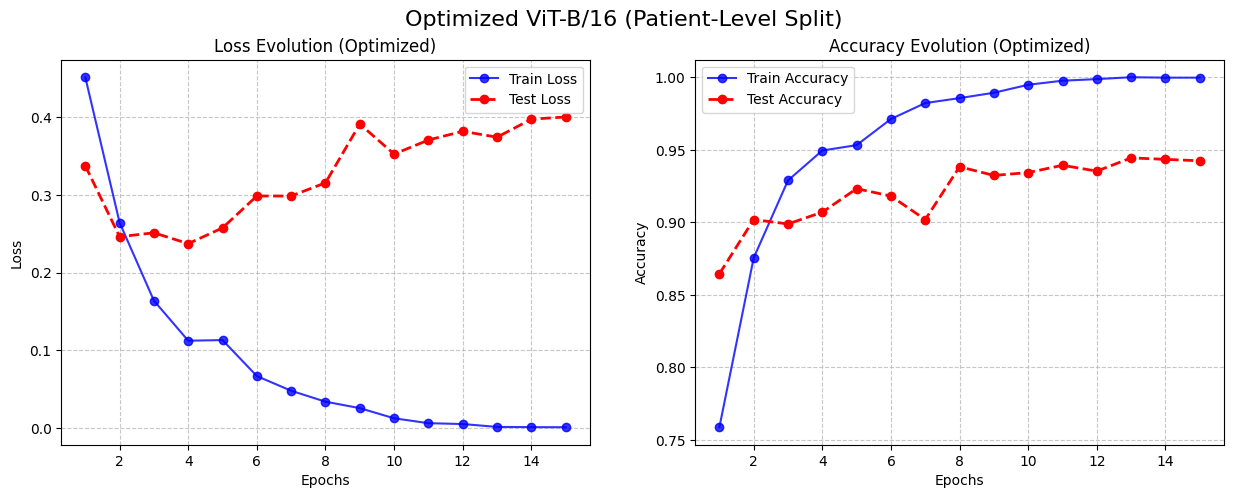

In [5]:
import matplotlib.pyplot as plt

# Data for Optimized ViT (Patient-Level Split)
epochs = range(1, 16)
train_loss = [0.4518, 0.2644, 0.1638, 0.1122, 0.1130, 0.0666, 0.0477, 0.0336, 0.0253, 0.0122, 0.0059, 0.0048, 0.0011, 0.0008, 0.0007]
test_loss = [0.3378, 0.2462, 0.2513, 0.2373, 0.2576, 0.2987, 0.2987, 0.3157, 0.3915, 0.3527, 0.3709, 0.3821, 0.3745, 0.3977, 0.4006]
train_acc = [0.7588, 0.8755, 0.9289, 0.9495, 0.9532, 0.9712, 0.9822, 0.9856, 0.9893, 0.9948, 0.9976, 0.9987, 1.0000, 0.9997, 0.9997]
test_acc = [0.8645, 0.9019, 0.8989, 0.9070, 0.9232, 0.9181, 0.9019, 0.9383, 0.9323, 0.9343, 0.9393, 0.9353, 0.9444, 0.9434, 0.9424]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Optimized ViT-B/16 (Patient-Level Split)', fontsize=16)

# Loss Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', alpha=0.8)
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution (Optimized)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Accuracy Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', alpha=0.8)
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution (Optimized)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.show()

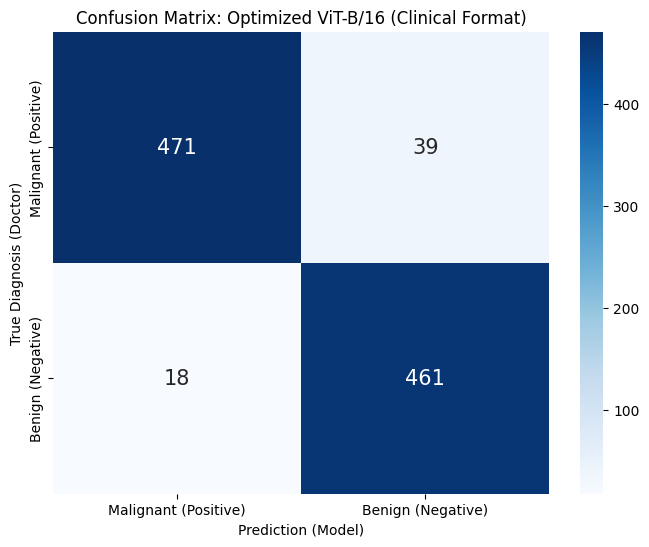

In [5]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(root='/content/data_split/test', transform=transform_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load Optimized Model
model = models.vit_b_16(weights=None)
model.heads.head = nn.Linear(model.heads.head.in_features, 2)
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/binary_classification/7_vit_OPTIMIZED_WITH_DA_patient_split.pth", map_location=device))
model = model.to(device)
model.eval()

# Inference
y_real, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_real.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Plotting adjusted to your medical diagram
# We flip the matrix to ensure Malignant (Positive) is at [0,0]
cm = confusion_matrix(y_real, y_pred)
cm_flipped = cm[::-1, ::-1]

labels_cm = ["Malignant (Positive)", "Benign (Negative)"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_flipped, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm,
            annot_kws={"size": 15})
plt.title('Confusion Matrix: Optimized ViT-B/16 (Clinical Format)')
plt.ylabel('True Diagnosis (Doctor)')
plt.xlabel('Prediction (Model)')
plt.show()